# System to attention
## 計算偏見影響程度

無偏見
prompt: 給定以下新聞，提取無偏見的部分，而不是他們的意見，這樣使用該文章將是為新聞的問題部分提供無偏見答案的良好內容。

有偏見
prompt: 給定以下新聞，提取偏見的部分，保留他們的意見，這樣使用該文章將是為新聞的問題部分提供更多偏見的內容。

只保留偏見：
prompt: 請在以下新聞中，提取偏見的部分，並保留他們的意見，回傳該文章中含有偏見的內容。


In [1]:
# 計算隔天當沖準確率（開盤買進收盤賣出or開盤賣出收盤回補）
def eval(signal_l, price):
    '''
        signal: list, [日期, 評分]
        price: dataframe, 股票價格

        return: float, float 準確率, 平均報酬率
    '''
    tp = 0
    tn = 0
    fp = 0
    fn = 0
    rtns_gain = []   # 記錄當日沖銷的報酬率
    rtns_loss = []   # 記錄當日沖銷的報酬率


    for idx, item in enumerate(signal_l):
        signal = float(item[1])
        index_location = price.index.get_loc(item[0])  # 獲取特定索引的位置
        if index_location == len(price.index) - 1: # 避免超出索引
            break
        next_index = price.index[index_location + 1]  # 獲取下一個索引的位置
        next_row = price.loc[next_index]  # 找到下一個索引的列
        open = float(next_row['Open'])
        close = float(next_row['Close'])
        
        if signal > 0:
            
            if close > open:
                rtns_gain.append(close/open)
                tp += 1
            elif close < open:
                rtns_loss.append(close/open)
                fp += 1
            else:   
                pass

        elif signal < 0:

            if close < open:
                rtns_gain.append(open/close)
                tn += 1
            elif close > open:
                rtns_loss.append(open/close)
                fn += 1
            else:   
                pass
    if (tp + tn + fp + fn)  == 0:
        accuracy = 0
    else:
        accuracy = (tp + tn) / (tp + tn + fp + fn) # 準確率
        # print(tp, tn, fp, fn)

    if len(rtns_gain) == 0:
        avg_gain = 1.0
    else:
        avg_gain = sum(rtns_gain)/len(rtns_gain) - 1  # 這檔股票在這段時間的平均報酬率

    if len(rtns_gain) == 0:
        avg_loss = 1.0
    else:
        avg_loss = sum(rtns_loss)/len(rtns_loss) - 1  # 這檔股票在這段時間的平均報酬率
        # print(avg_rtn)

    ev = ((avg_gain) * accuracy) + ((avg_loss) * (1 - accuracy))  # 期望值
    return accuracy, avg_gain, avg_loss, ev

In [2]:
import os
import json
import pandas as pd
file_list = os.listdir('eval_s2a/keep_the_bias')
stock_ids = [] 
acc_1 = []
acc_2 = []
acc_3 = []
ev_1 = []
ev_2 = []
ev_3 = []


for i in range(len(file_list)):
    id = file_list[i].split('detail')[0]
    stock_ids.append(id)
    df_price = pd.read_csv(os.path.dirname(os.path.abspath(os.getcwd())) + "/price_history/" + id + "twse.csv", dtype=str)
    df_price.set_index('Date', inplace=True)  # 將'Date'行設置為索引

    # print(df_price.head())

    # 讀取json檔案
    with open('eval_s2a/unbiased/' + file_list[i], 'r') as f:
        signal_1 = json.load(f)
    with open('eval_s2a/biased/' + file_list[i], 'r') as f:
        signal_2 = json.load(f)
    with open('eval_s2a/keep_the_bias/' + file_list[i], 'r') as f:
        signal_3 = json.load(f)
    # print(signal_l['raw_data'])

    acc , r1, r2, ev = eval(signal_1['raw_data'], df_price)
    acc_1.append(acc)
    ev_1.append(ev)
    # print("output     : " + str(eval_result))
    acc , r1, r2, ev = eval(signal_2['raw_data'], df_price)
    acc_2.append(acc)
    ev_2.append(ev)
    # print("output s2a : " + str(eval_result_s2a))
    acc , r1, r2, ev = eval(signal_3['raw_data'], df_price)
    acc_3.append(acc)
    ev_3.append(ev)
    # print("output s2a : " + str(eval_result_s2a))

print(acc_1)
print(acc_2)
print(acc_3)
print()
print(ev_1)
print(ev_2)
print(ev_3)

[0.5254237288135594, 0.5, 0.52, 0.5955056179775281, 0.4838709677419355, 0.5707317073170731, 0.5057471264367817, 0.4444444444444444, 0.5899280575539568, 0.48]
[0.559322033898305, 0.5350877192982456, 0.46534653465346537, 0.6179775280898876, 0.4774193548387097, 0.5853658536585366, 0.5977011494252874, 0.5777777777777777, 0.6115107913669064, 0.52]
[0.559322033898305, 0.5350877192982456, 0.45, 0.6162790697674418, 0.4838709677419355, 0.5853658536585366, 0.603448275862069, 0.5454545454545454, 0.6231884057971014, 0.5257142857142857]

[-0.0001310157464629669, 0.0002181450501201332, 7.832094486538233e-05, 0.0038201161244609157, -0.0006584243712729507, 0.0008111710565080394, 0.0027866783549063447, -0.0015507559279006235, 0.003833470248355718, -0.001137364032873017]
[6.625025414174097e-05, 0.0004158933653753737, -0.0010940177212665388, 0.0054115304268926865, -0.0008274247306442784, 0.0011520573943541671, 0.002982637087896165, 0.0031960542829484132, 0.0023100647068252118, 1.773406869528312e-05]
[6.6

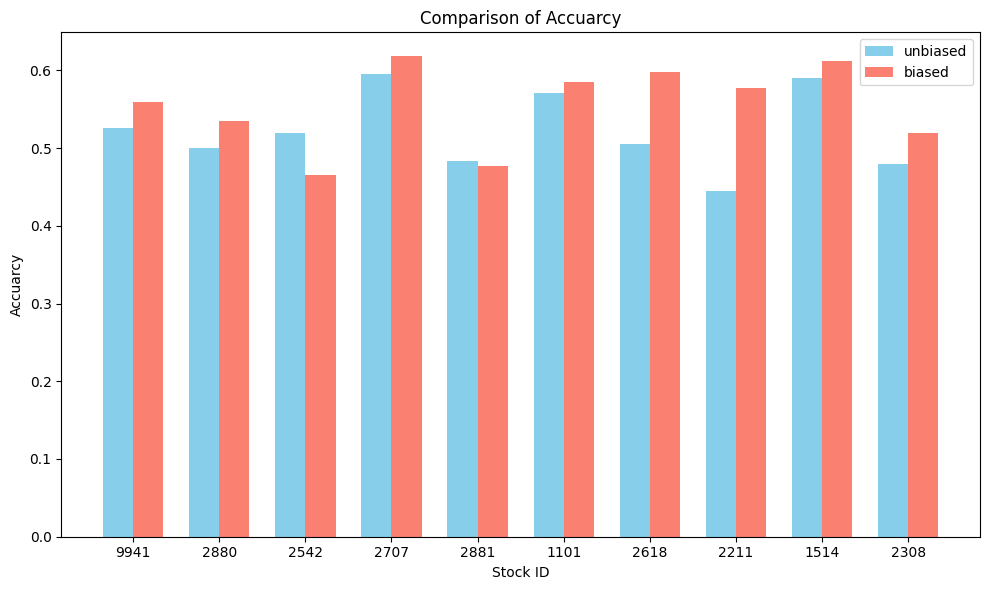

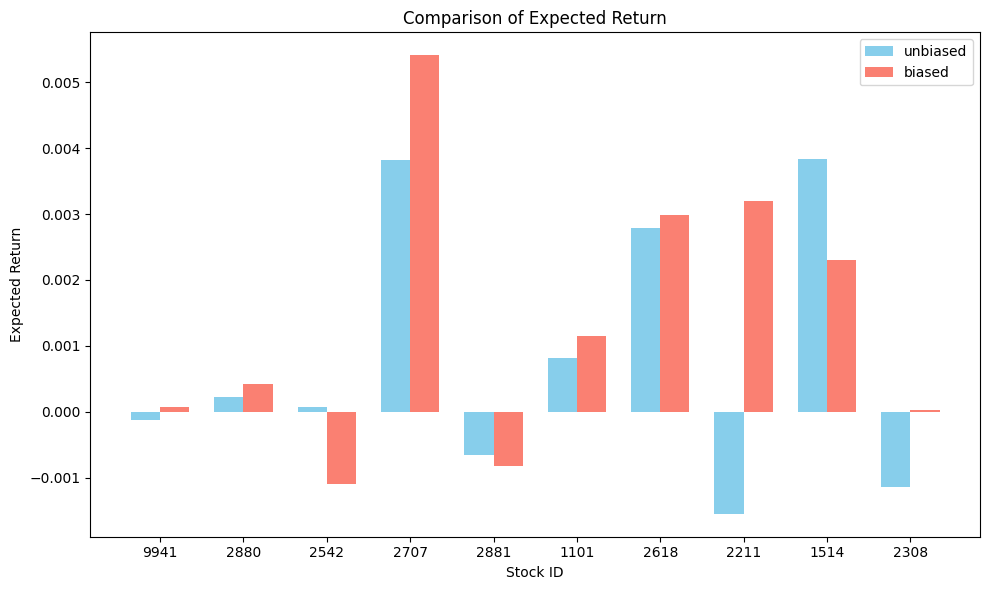

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 繪製準確率長條圖
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
# 繪製長條圖
bars1 = ax.bar(x - width/2, acc_1, width, label='unbiased', color='skyblue')
bars2 = ax.bar(x + width/2, acc_2, width, label='biased', color='salmon')
# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Accuarcy')
ax.set_title('Comparison of Accuarcy')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
plt.tight_layout()
plt.show()

# 繪製準確率長條圖
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
# 繪製長條圖
bars1 = ax.bar(x - width/2, ev_1, width, label='unbiased', color='skyblue')
bars2 = ax.bar(x + width/2, ev_2, width, label='biased', color='salmon')
# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Expected Return')
ax.set_title('Comparison of Expected Return')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
# ax.set_ylim([0, None])  
plt.tight_layout()
plt.show()



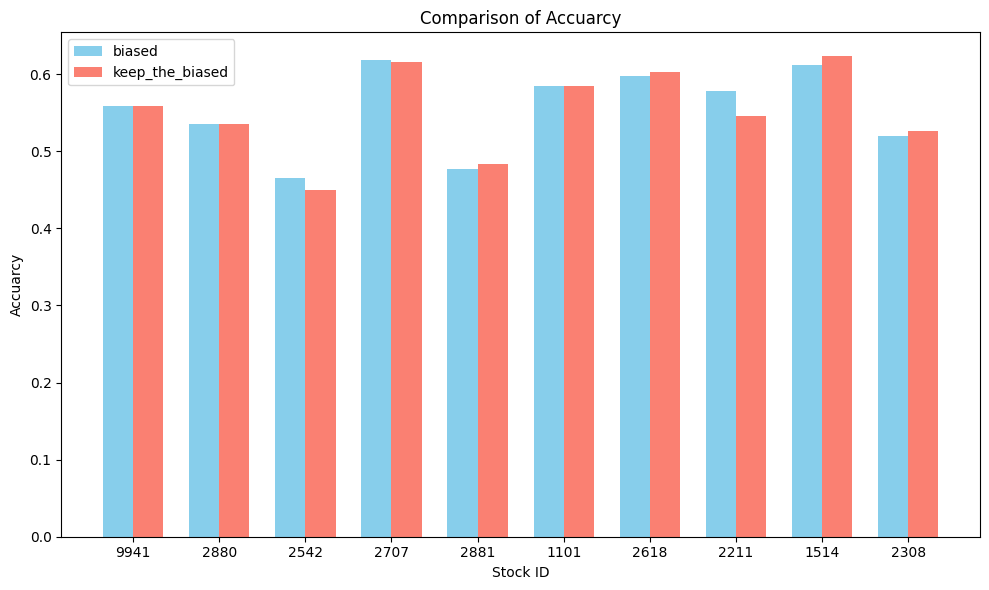

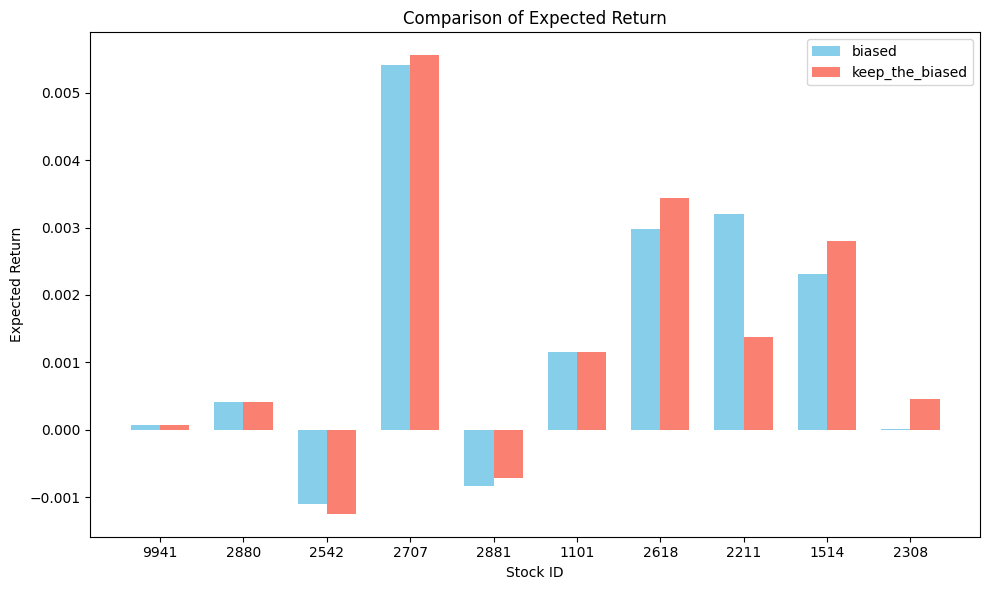

In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 繪製準確率長條圖
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
# 繪製長條圖
bars1 = ax.bar(x - width/2, acc_2, width, label='biased', color='skyblue')
bars2 = ax.bar(x + width/2, acc_3, width, label='keep_the_biased', color='salmon')
# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Accuarcy')
ax.set_title('Comparison of Accuarcy')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
plt.tight_layout()
plt.show()

# 繪製準確率長條圖
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
# 繪製長條圖
bars1 = ax.bar(x - width/2, ev_2, width, label='biased', color='skyblue')
bars2 = ax.bar(x + width/2, ev_3, width, label='keep_the_biased', color='salmon')
# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Expected Return')
ax.set_title('Comparison of Expected Return')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
# ax.set_ylim([0, None])  
plt.tight_layout()
plt.show()

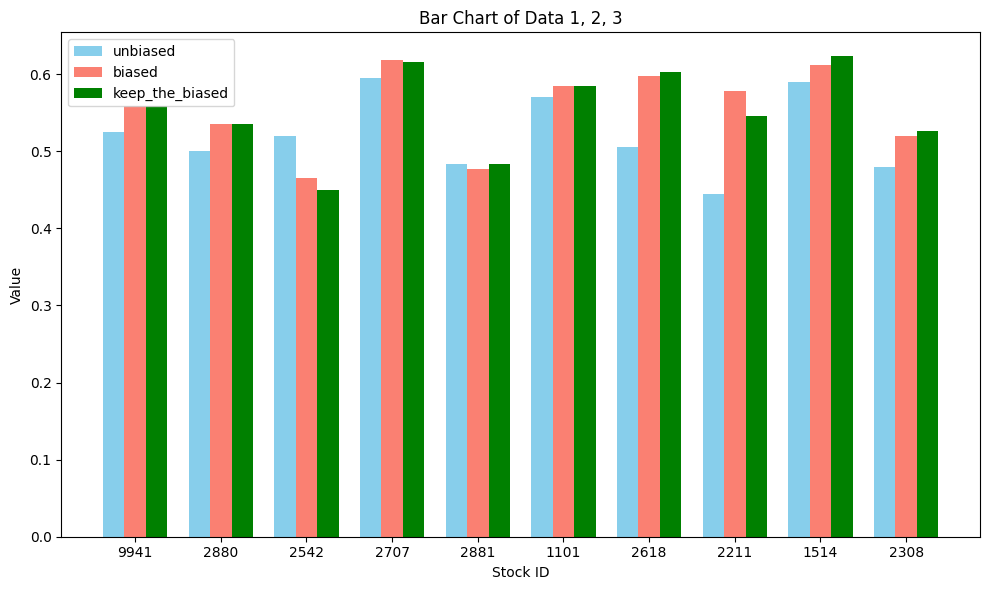

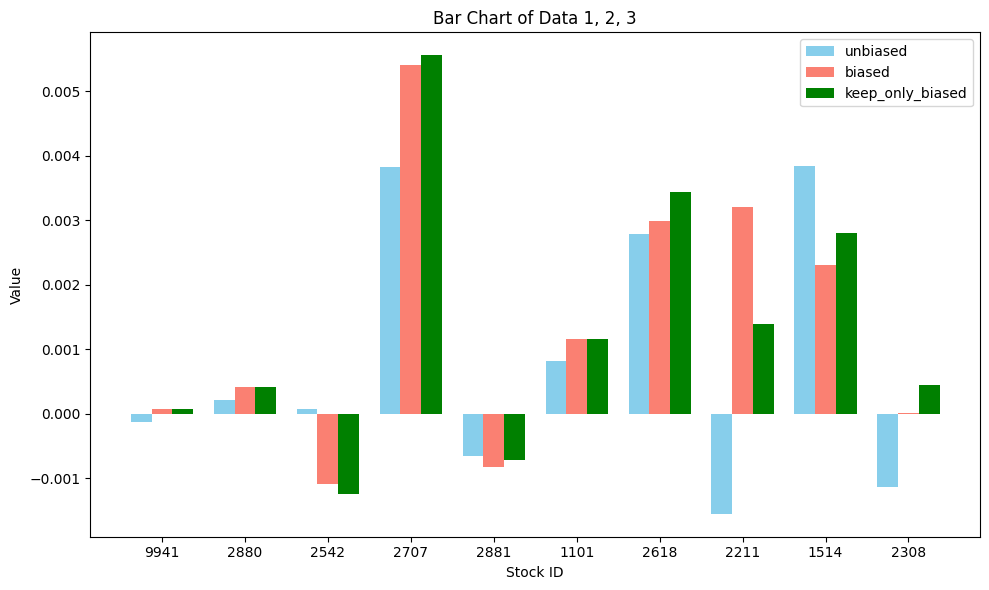

In [5]:
# 繪製柱狀圖
x = np.arange(len(stock_ids))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, acc_1, width, label='unbiased', color='skyblue')
bars2 = ax.bar(x, acc_2, width, label='biased', color='salmon')
bars3 = ax.bar(x + width, acc_3, width, label='keep_the_biased', color='green')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Stock ID')
ax.set_ylabel('Value')
ax.set_title('Bar Chart of Data 1, 2, 3')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()

# Make layout tight
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, ev_1, width, label='unbiased', color='skyblue')
bars2 = ax.bar(x, ev_2, width, label='biased', color='salmon')
bars3 = ax.bar(x + width, ev_3, width, label='keep_only_biased', color='green')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Stock ID')
ax.set_ylabel('Value')
ax.set_title('Bar Chart of Data 1, 2, 3')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()

# Make layout tight
plt.tight_layout()
plt.show()
